In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.12.1+cu130
Device: cpu


In [2]:
df = pd.read_csv("loan_default_dataset.csv")
print(df.shape)
df.head()

(5000, 14)


,Age,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Employment_Years,Num_Credit_Lines,Debt_To_Income_Ratio,Num_Late_Payments,Has_Mortgage,Education,Loan_Purpose,Marital_Status,Loan_Default
0,60,98484,12490,36,388,12,4,0.24,2,1,Master,Education,Single,0
1,50,138747,29502,48,710,12,3,0.18,4,1,High School,Personal,Married,0
2,36,33026,40757,60,540,23,2,0.53,0,0,Bachelor,Business,Single,0
3,64,88309,46111,36,522,23,2,0.10,8,1,Bachelor,Home,Married,0
4,29,65927,88245,24,767,13,8,0.19,7,1,Master,Education,Single,0


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean = df.copy()

for col in ['Education', 'Loan_Purpose', 'Marital_Status']:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean['Loan_To_Income'] = df_clean['Loan_Amount'] / df_clean['Annual_Income']
df_clean['Risk_Score'] = (df_clean['Num_Late_Payments'] * 2 +
                           df_clean['Debt_To_Income_Ratio'] * 10 -
                           df_clean['Credit_Score'] / 100)

X = df_clean.drop(columns=['Loan_Default']).values.astype(np.float32)
y = df_clean['Loan_Default'].values.astype(np.int64)

print("X:", X.shape)
print("y:", y.shape)

X: (5000, 15)
y: (5000,)


In [4]:
# normalize
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X = (X - X_mean) / X_std

# train test split 80/20
split = int(0.8 * len(X))
idx = np.random.permutation(len(X))

X_train_np, X_test_np = X[idx[:split]], X[idx[split:]]
y_train_np, y_test_np = y[idx[:split]], y[idx[split:]]

print("train:", X_train_np.shape)
print("test:", X_test_np.shape)

train: (4000, 15)
test: (1000, 15)


In [5]:
# converting to pytorch tensors
# X -> FloatTensor (continuous values)
# y -> LongTensor (class labels)

X_train = torch.FloatTensor(X_train_np)
X_test  = torch.FloatTensor(X_test_np)
y_train = torch.LongTensor(y_train_np)
y_test  = torch.LongTensor(y_test_np)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

X_train: torch.Size([4000, 15]) torch.float32
y_train: torch.Size([4000]) torch.int64


In [6]:
# building the MLP using nn.Module

class LoanMLP(nn.Module):
    def __init__(self, input_dim):
        super(LoanMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.drop1(x)
        x = self.relu2(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

model = LoanMLP(X_train.shape[1])
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

LoanMLP(
  (fc1): Linear(in_features=15, out_features=64, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)
parameters: 3170


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# training loop - 20 epochs

losses = []
accuracies = []

model.train()
for epoch in range(20):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()

    _, preds = torch.max(out, 1)
    acc = (preds == y_train).float().mean().item()

    losses.append(loss.item())
    accuracies.append(acc)

    print(f"epoch {epoch+1}/20  loss: {loss.item():.4f}  acc: {acc*100:.2f}%")

epoch 1/20  loss: 0.6405  acc: 74.10%
epoch 2/20  loss: 0.6271  acc: 77.40%
epoch 3/20  loss: 0.6192  acc: 78.32%
epoch 4/20  loss: 0.6063  acc: 79.15%
epoch 5/20  loss: 0.5992  acc: 79.40%
epoch 6/20  loss: 0.5906  acc: 79.55%
epoch 7/20  loss: 0.5811  acc: 79.52%
epoch 8/20  loss: 0.5729  acc: 79.55%
epoch 9/20  loss: 0.5654  acc: 79.55%
epoch 10/20  loss: 0.5572  acc: 79.55%
epoch 11/20  loss: 0.5514  acc: 79.55%
epoch 12/20  loss: 0.5454  acc: 79.55%
epoch 13/20  loss: 0.5401  acc: 79.55%
epoch 14/20  loss: 0.5318  acc: 79.55%
epoch 15/20  loss: 0.5288  acc: 79.55%
epoch 16/20  loss: 0.5227  acc: 79.55%
epoch 17/20  loss: 0.5210  acc: 79.55%


epoch 18/20  loss: 0.5152  acc: 79.55%
epoch 19/20  loss: 0.5147  acc: 79.55%
epoch 20/20  loss: 0.5142  acc: 79.55%


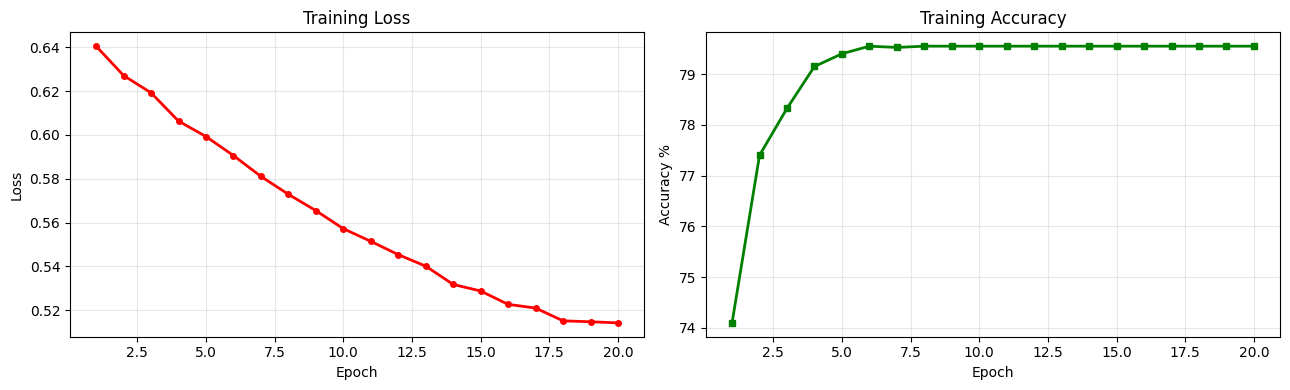

In [9]:
# loss curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, 21), losses, color='red', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, 21), [a*100 for a in accuracies], color='green', linewidth=2, marker='s', markersize=4)
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# evaluation on test set
model.eval()
with torch.no_grad():
    test_out = model(X_test)
    test_loss = criterion(test_out, y_test).item()
    _, test_preds = torch.max(test_out, 1)
    test_acc = (test_preds == y_test).float().mean().item()

from sklearn.metrics import classification_report, f1_score

y_true = y_test.numpy()
y_pred = test_preds.numpy()

print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_acc*100:.2f}%")
print(f"f1 score: {f1_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['No Default', 'Default']))

test loss: 0.4837
test accuracy: 81.00%
f1 score: 0.0000

              precision    recall  f1-score   support

  No Default       0.81      1.00      0.90       810
     Default       0.00      0.00      0.00       190

    accuracy                           0.81      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.66      0.81      0.72      1000



In [11]:
# numpy vs pytorch tensor difference
import numpy as np

arr = np.array([1.0, 2.0, 3.0])
tensor = torch.FloatTensor([1.0, 2.0, 3.0])

print("numpy array:", arr, "| dtype:", arr.dtype)
print("torch tensor:", tensor, "| dtype:", tensor.dtype)
print()
print("numpy - no gradient tracking")
print("pytorch - has autograd, can run on GPU")

# gradient example
x = torch.tensor(3.0, requires_grad=True)
y_val = x ** 2
y_val.backward()
print()
print(f"x=3, y=x^2={y_val.item()}, gradient dy/dx={x.grad.item()} (should be 6)")

numpy array: [1. 2. 3.] | dtype: float64
torch tensor: tensor([1., 2., 3.]) | dtype: torch.float32

numpy - no gradient tracking
pytorch - has autograd, can run on GPU

x=3, y=x^2=9.0, gradient dy/dx=6.0 (should be 6)


In [12]:
# why relu not sigmoid
print("ReLU: f(x) = max(0, x)")
print("Sigmoid: f(x) = 1 / (1 + e^-x)")
print()
print("sigmoid gradient gets very small for large/small x -> vanishing gradient problem")
print("relu gradient = 1 for x>0, so gradients dont disappear in deep networks")
print("thats why relu is preferred in hidden layers")

ReLU: f(x) = max(0, x)
Sigmoid: f(x) = 1 / (1 + e^-x)

sigmoid gradient gets very small for large/small x -> vanishing gradient problem
relu gradient = 1 for x>0, so gradients dont disappear in deep networks
thats why relu is preferred in hidden layers
